# Pytorch Playground

Deep learning framework aid in development and deployment of neural networks. Some of the popular frameworks are JAX, pytorch, and others. Matplotlib and numpy are other framework for visualization and numerical computation.

In [18]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Subset
from torchvision import datasets, transforms

## Tensors
However, in all the frameworks a data structure called **tensors** is used. The tensors are allocated and initialized using different functions.


In [19]:
x1 = torch.tensor([[2, 1]]) #2-d tensor
x2 = torch.tensor([[1],[2]])
C = torch.mm(x1,x2)
print(C)

tensor([[4]])


Some of the functions are in sub-libraries. e.g. torch.nn.functional.

In [20]:
import torch.nn.functional as F
x2 = torch.tensor([2, 1, -0.5])
relu_out = F.relu(x2)
print(f"ReLU: {relu_out}")

ReLU: tensor([2., 1., 0.])


**Task 1**: Use one of the functions and visualize it with matplotlib.
* zeros()
* ones()
* randn()
* eye()
* others

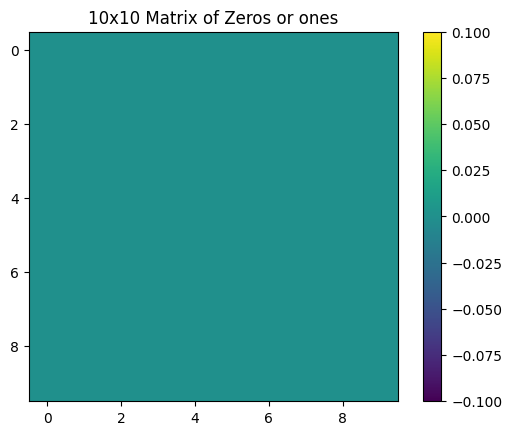

In [21]:
data = torch.zeros((10, 10)) 
#data= torch.ones((10, 10))      # 10x10 Matrix with ones
plt.imshow(data, cmap='viridis')  # Display the matrix as a heatmap 
plt.colorbar()
plt.title("10x10 Matrix of Zeros or ones")
plt.show()

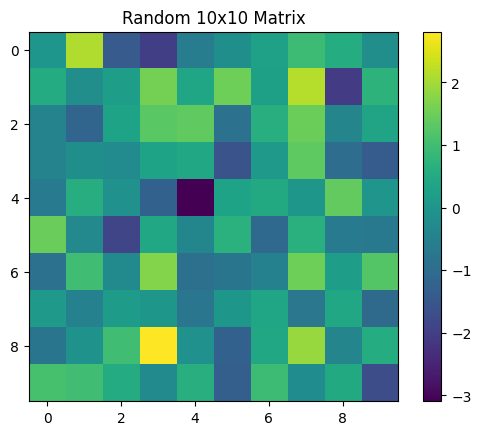

In [22]:
#TODO
# random heatmap example using a 10x10 matrix of random values
data = torch.randn(10, 10)       # 10x10 Matrix with random values
plt.imshow(data, cmap='viridis')  # Display the matrix as a heatmap
plt.colorbar()
plt.title("Random 10x10 Matrix")
plt.show()

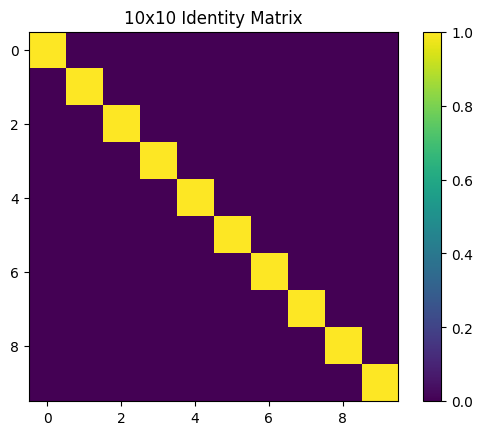

In [23]:
data = torch.eye(10)  # 10x10 Identity matrix
plt.imshow(data, cmap='viridis')  # Display the matrix as a heatmap
plt.colorbar()
plt.title("10x10 Identity Matrix")
plt.show()

## Data and Dataset

Training machine learning needs large datasets. These can be images, audio, words, and others represented as tensors. **MNIST** is a data containing grayscale images of handwritten digits (0-9) with resolution of 28x28 pixels. It not only contains images but als ground truth labels.  The dataset has 60,000 training images and 10,000 test images

 The original paper in 1989 used only 7291 training images and 2007 test images of 16x16 pixels.  The images in MNIST Dataset are resized from 28x28 to 16x16. Furthermore, the pixels are scaled from (0,255) to (0,1)

In [24]:
transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor() #from (0,255) to (0,1)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_subset_size = 7291
test_subset_size = 2007
train_subset = torch.utils.data.Subset(train_dataset, range(train_subset_size))
test_subset = torch.utils.data.Subset(test_dataset, range(test_subset_size))

Shape is a important concept in deep learning, as it indicates the organization of data, MNIST images in PyTorch are always stored as $C \times H \times W$ (Channels, Height, Width). The image pixel in MNIST is grayscale therefore, the number of channels is 1.



**Task 2** Find out the shape in an MNIST image. Visualize a sample image with its label using matplotlib.

Image shape: torch.Size([1, 16, 16]), Label: 5


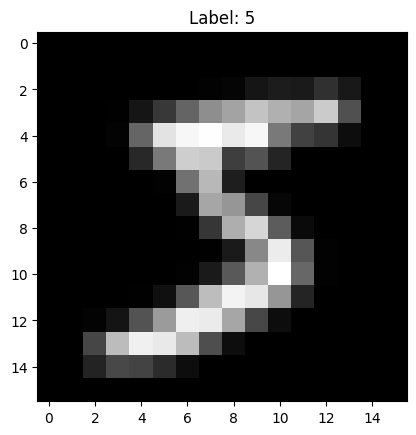

In [25]:
#TODO
image,label = train_subset[0]
print(f"Image shape: {image.shape}, Label: {label}")
plt.imshow(image.squeeze(), cmap='gray') #squeeze to remove the channel dimension (1,16,16) -> (16,16) matplotlib expects 2D array for grayscale images
plt.title(f"Label: {label}")
plt.show()



## Data preprocesing

Data preprocessing plays a major role in Machine Learning training.

In [ ]:
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=len(train_subset), shuffle=True) #batch size is set to the size of the subset to load all data at once, shuffle is set to true to randomize the order of the data
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=len(test_subset), shuffle=True)#batch size is set to the size of the subset to load all data at once, shuffle is set to true to randomize the order of the data
x_train, y_train = next(iter(train_loader))#load all data at once, shuffle is set to true to randomize the order of the data
x_test, y_test = next(iter(test_loader))
dataset_dict = {
    'train': (x_train, y_train, 7291),
    'test': (x_test, y_test, 2007)
}#dataset_dict is a dictionary that contains the training and testing data, where the keys are 'train' and 'test', and the values are tuples containing the input data (x), the labels (y), and the number of samples (n) in each dataset. This dictionary will be used to process and save the data in a specific format for later use.

for split_name, (x_raw, y_raw, n) in dataset_dict.items(): #iterate over the dataset_dict, where split_name is the key ('train' or 'test'), x_raw is the input data, y_raw is the labels, and n is the number of samples in each dataset. This loop will process the data and save it in a specific format for later use.
    x_processed = (x_raw[:n] * 2.0) - 1.0 #scale the input data from (0,1) to (-1,1) by multiplying by 2 and subtracting 1. This is a common preprocessing step for neural networks to improve convergence during training.
    y_processed = F.one_hot(y_raw[:n], num_classes=10).float() #convert the labels to one-hot encoding, where each label is represented as a binary vector of length 10 (the number of classes in the MNIST dataset). This is done using the F.one_hot function from PyTorch, which takes the raw labels and the number of classes as input and returns a tensor of shape (n, 10) where n is the number of samples in the dataset. The .float() method is used to convert the one-hot encoded labels to floating-point numbers, which is a common format for training neural networks. for example, if the label is 3, the one-hot encoding will be [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].
    y_processed = (y_processed * 2.0) - 1.0 #scale the one-hot encoded labels from (0,1) to (-1,1) by multiplying by 2 and subtracting 1. This is done to match the scaling of the input data and to improve convergence during training.
    x_final = x_processed.numpy().astype(np.float32) #convert the processed input data from a PyTorch tensor to a NumPy array and change the data type to float32. This is done to save the data in a specific format for later use, such as training a neural network in a different framework that may require NumPy arrays as input.
    y_final = y_processed.numpy().astype(np.float32)
    filename = f"./data/{split_name}1989.npz"#create a filename for saving the processed data, where split_name is either 'train' or 'test', and the number 1989 is added to indicate the year of the dataset. The .npz extension indicates that the file will be saved in NumPy's compressed format, which allows for efficient storage of large arrays.
    np.savez(filename, X=x_final, Y=y_final)#save the processed input data (x_final) and the processed labels (y_final) in a compressed NumPy file using the np.savez function. The data is saved with the keys 'X' for the input data and 'Y' for the labels, which can be easily loaded later for training a neural network or for other purposes.


**Task 3**: However, the initial paper had different number of training and test images and dimensions. The notebook in above code cell is preprocessing the dataset and writes the preprocessed data in a file. Write in following markdown cell the characteristics of the dataset and in what format is the file? what is npz format?

#TODO
